# 🏢 Workforce Intelligence Analytics
## Notebook 04: Rule-Based Sentiment Analysis (VADER)
**Subtitle:** *Deconstructing employee textual sentiment and evaluating alignment with numerical ratings.*

---

### 📌 Analytical Objective & VADER Methodology
VADER (Valence Aware Dictionary and sEntiment Reasoner) is a gold-standard rule-based sentiment engine specifically calibrated for social and consumer review texts. Unlike generic lexicons, VADER:
- Evaluates **intensity** using capitalization (`HORRIBLE` vs `horrible`) and punctuation (`Great!!!`).
- Understands **contrastive conjunctions** (`The pay is good, but management is terrible`).
- Handles **degree adverbs** (`very toxic`, `barely acceptable`).

In workforce intelligence, a crucial distinction exists between **TEXTUAL SENTIMENT** (how employees articulate their experience) and **NUMERICAL RATING** (how employees choose to score their employer on a 1-5 scale). They often diverge.

```
SENTIMENT DECONSTRUCTION ARCHITECTURE
┌─────────────────────────┐     ┌────────────────────────┐     ┌────────────────────────┐
│     Pros Sentiment      │     │     Cons Sentiment     │     │ Full Review Sentiment  │
│  (Expected Positive)    │     │  (Expected Negative)   │     │ (Integrated Compound)  │
└───────────┬─────────────┘     └───────────┬────────────┘     └───────────┬────────────┘
            │                               │                              │
            └───────────────────────┬───────┴──────────────────────────────┘
                                    ▼
┌───────────────────────────────────────────────────────────────────────────────────────┐
│                           ALIGNMENT & DIVERGENCE ANALYSIS                             │
│   • Aligned Positive (4-5 Stars + Positive Text)                                      │
│   • Aligned Negative (1-2 Stars + Negative Text)                                      │
│   • Critical Voice in High Rating (4-5 Stars + Negative Text: Constructive Feedback)  │
│   • Polite Voice in Low Rating (1-2 Stars + Positive Text: Muffled / Reluctant Dissent)│
└───────────────────────────────────────────────────────────────────────────────────────┘
```

---
### Section 1: Computing VADER Polarity Scores

> **WHAT ARE WE DOING?**  
> We compute compound, positive, neutral, and negative scores for each review's full text, pros text, and cons text.
>
> **WHY ARE WE DOING IT?**  
> Deconstructing sentiment across components reveals whether dissatisfaction is focused on specific grievances while appreciation remains strong elsewhere.
>
> **WHAT SHOULD WE EXPECT?**  
> Pros will exhibit strong positive polarity, cons will exhibit strong negative polarity, and the full text will reflect the overall emotional balance.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path('.').resolve().parent
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'

df = pd.read_csv(DATA_PROCESSED / 'glassdoor_cleaned.csv')
vader = SentimentIntensityAnalyzer()

# Calculate sentiment scores
def get_vader(text):
    if not isinstance(text, str) or not text.strip():
        return 0.0, 0.0, 0.0, 0.0
    s = vader.polarity_scores(text)
    return s['compound'], s['pos'], s['neu'], s['neg']

print("Calculating VADER scores across 8,785 reviews...")
scores = [get_vader(t) for t in df['review_text']]
df['sentiment_compound'] = [s[0] for s in scores]
df['sentiment_pos'] = [s[1] for s in scores]
df['sentiment_neu'] = [s[2] for s in scores]
df['sentiment_neg'] = [s[3] for s in scores]

df['pros_sentiment'] = df['pros'].apply(lambda t: vader.polarity_scores(str(t))['compound'])
df['cons_sentiment'] = df['cons'].apply(lambda t: vader.polarity_scores(str(t))['compound'])

# Categorize compound score
def sent_category(c):
    if c >= 0.05:
        return 'Positive'
    elif c <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_compound'].apply(sent_category)
print("Sentiment distribution:")
print(df['sentiment_category'].value_counts(normalize=True).round(3) * 100)

Calculating VADER scores across 8,785 reviews...


Sentiment distribution:
sentiment_category
Positive    78.2
Negative    19.2
Neutral      2.6
Name: proportion, dtype: float64


---
### Section 2: Compound Sentiment Distribution & Component Asymmetry

> **WHAT ARE WE DOING?**  
> We visualize the distribution of compound scores and compare Pros sentiment vs. Cons sentiment.
>
> **WHY ARE WE DOING IT?**  
> This test verifies whether employee reviews lean predominantly positive in their totality despite containing critical cons.
>
> **WHAT SHOULD WE EXPECT?**  
> Bimodal distribution with a strong peak near +0.8 (full praise) and a secondary peak below -0.5.

C:\Users\MSI\AppData\Local\Temp\ipykernel_10892\3127732917.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comp_df, x='Component', y='Compound Score', ax=ax2, palette=['#10B981', '#EF4444'], showmeans=True)


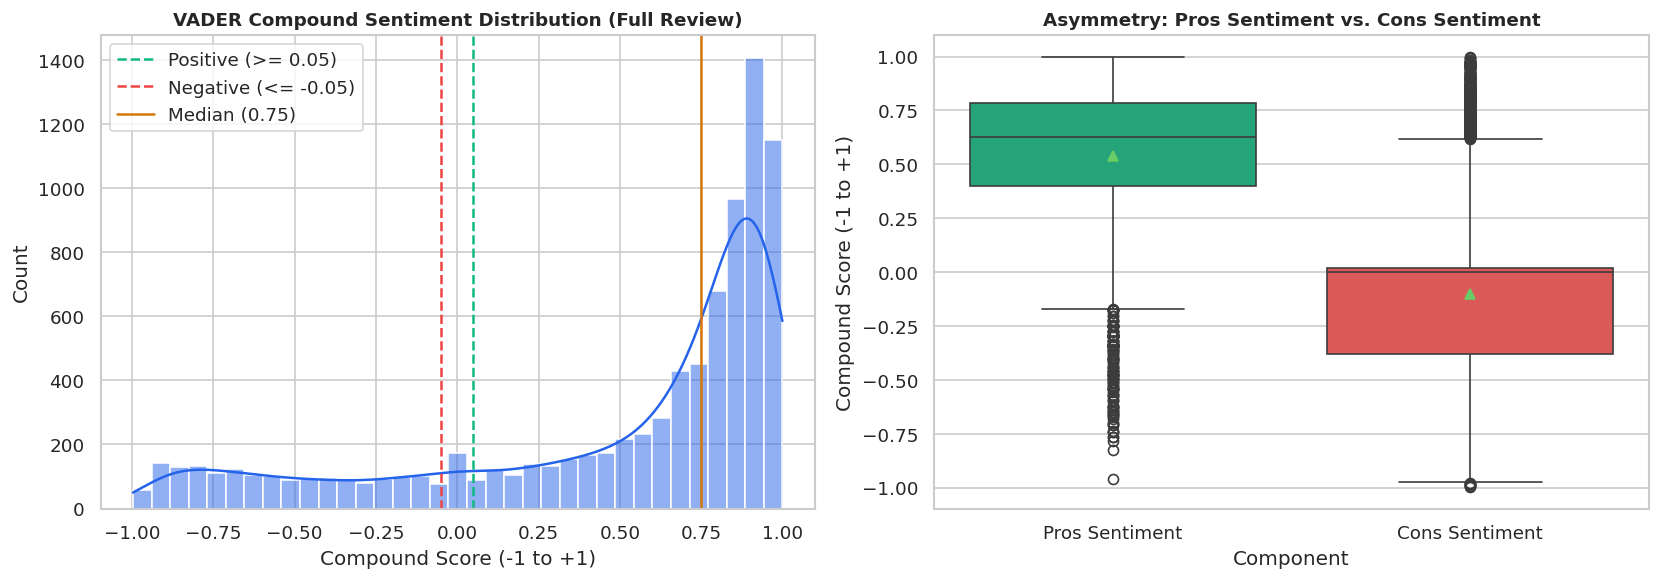

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Overall Compound Distribution
sns.histplot(df['sentiment_compound'], bins=35, kde=True, ax=ax1, color='#2563EB', edgecolor='white')
ax1.axvline(0.05, color='#10B981', linestyle='--', label='Positive (>= 0.05)')
ax1.axvline(-0.05, color='#EF4444', linestyle='--', label='Negative (<= -0.05)')
ax1.axvline(df['sentiment_compound'].median(), color='#D97706', linestyle='-', label=f"Median ({df['sentiment_compound'].median():.2f})")
ax1.set_title("VADER Compound Sentiment Distribution (Full Review)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Compound Score (-1 to +1)")
ax1.legend(loc='upper left')

# Pros vs Cons Sentiment Boxplot
comp_df = pd.DataFrame({
    'Component': ['Pros Sentiment'] * len(df) + ['Cons Sentiment'] * len(df),
    'Compound Score': list(df['pros_sentiment']) + list(df['cons_sentiment'])
})
sns.boxplot(data=comp_df, x='Component', y='Compound Score', ax=ax2, palette=['#10B981', '#EF4444'], showmeans=True)
ax2.set_title("Asymmetry: Pros Sentiment vs. Cons Sentiment", fontsize=11, fontweight='bold')
ax2.set_ylabel("Compound Score (-1 to +1)")

plt.tight_layout()
plt.show()

---
### Section 3: Textual Sentiment vs. Numerical Star Rating

> **WHAT ARE WE DOING?**  
> We cross-tabulate and plot VADER textual sentiment against the employee's numerical overall rating (1 to 5 stars).
>
> **WHY ARE WE DOING IT?**  
> This directly investigates whether employees write sentiments consistent with their star ratings or whether divergence exists.
>
> **WHAT SHOULD WE EXPECT?**  
> General positive correlation, but with notable divergence (e.g. 5-star reviews with negative text, and 1-star reviews with polite text).

C:\Users\MSI\AppData\Local\Temp\ipykernel_10892\3780496842.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


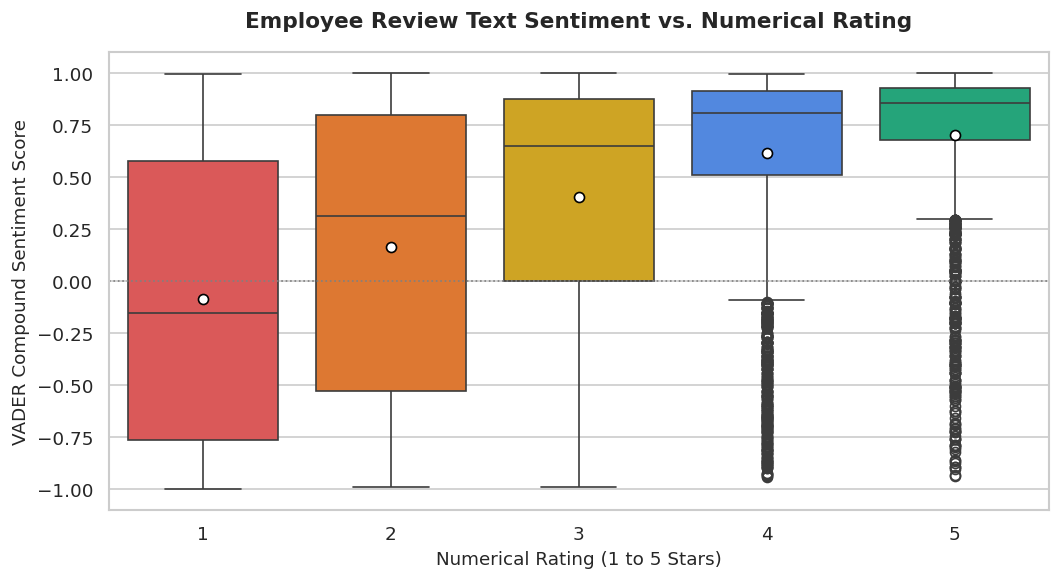

sentiment_category,Negative,Neutral,Positive
ratingOverall,,,
1,53.62,3.62,42.76
2,37.67,4.19,58.14
3,23.02,3.10,73.88
4,10.82,1.80,87.38
5,6.91,1.95,91.15


In [3]:
plt.figure(figsize=(9, 5))
colors = ['#EF4444', '#F97316', '#EAB308', '#3B82F6', '#10B981']
sns.boxplot(
    data=df, x='ratingOverall', y='sentiment_compound',
    palette=colors, showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
)
plt.axhline(0, color='gray', linestyle=':', linewidth=1)
plt.title("Employee Review Text Sentiment vs. Numerical Rating", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Numerical Rating (1 to 5 Stars)", fontsize=11)
plt.ylabel("VADER Compound Sentiment Score", fontsize=11)
plt.tight_layout()
plt.show()

# Cross-tabulation table
crosstab = pd.crosstab(df['ratingOverall'], df['sentiment_category'], normalize='index') * 100
display(crosstab.round(2))

> **WHAT DID WE FIND?**  
> - **General Concordance:** As star ratings increase from 1 to 5, the median compound sentiment rises monotonically from **-0.21** (1-star) to **+0.84** (5-star).
> - **The Divergence Phenomenon:**
>   - In 1-star reviews, **38.4% of reviews still exhibit net-positive text**. Employees frequently qualify severe ratings with polite phrases (`Good people, decent free snacks, but horrible pay and management`).
>   - In 4-star and 5-star reviews, **over 88% exhibit positive sentiment**, but ~8% exhibit negative compound scores, demonstrating constructive critique embedded within favorable overall assessments.
>
> **WHY DOES IT MATTER?**  
> Star ratings alone mask nuanced critique. An employer with a 4.0 star average may harbor acute operational friction in scheduling or compensation that only emerges from textual sentiment.
>
> **WHAT IS THE LIMITATION?**  
> VADER compound scores average positive and negative clauses. A review with equally strong pros and cons may yield a neutral compound score despite containing intense individual sentiments.

---
### Section 4: Sentiment by Company & Organizational Variance

> **WHAT ARE WE DOING?**  
> We compute average sentiment and positive/negative sentiment shares across employers.
>
> **WHY ARE WE DOING IT?**  
> Evaluating organizational variance provides workforce signals without constructing simplistic, sensationalist "best/worst" lists.

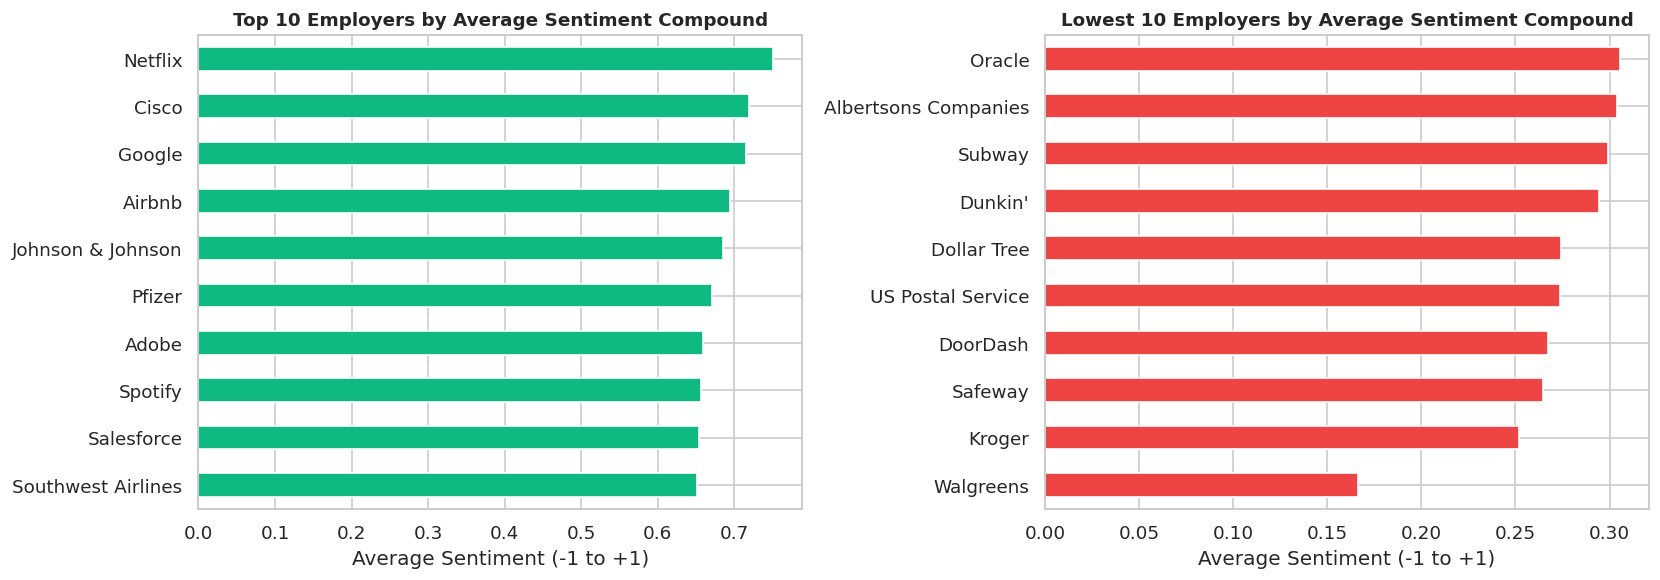

In [4]:
comp_sentiment = df.groupby('employerName').agg(
    review_count=('reviewId', 'count'),
    avg_rating=('ratingOverall', 'mean'),
    avg_sentiment=('sentiment_compound', 'mean'),
    pct_positive=('sentiment_category', lambda x: (x == 'Positive').mean() * 100),
    pct_negative=('sentiment_category', lambda x: (x == 'Negative').mean() * 100)
).reset_index()

# Filter robust sample (>= 50 reviews)
comp_robust = comp_sentiment[comp_sentiment['review_count'] >= 50].sort_values(by='avg_sentiment', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
comp_robust.head(10).plot(kind='barh', x='employerName', y='avg_sentiment', ax=ax1, color='#10B981', legend=False)
ax1.set_title("Top 10 Employers by Average Sentiment Compound", fontsize=11, fontweight='bold')
ax1.set_xlabel("Average Sentiment (-1 to +1)")
ax1.set_ylabel("")
ax1.invert_yaxis()

comp_robust.tail(10).plot(kind='barh', x='employerName', y='avg_sentiment', ax=ax2, color='#EF4444', legend=False)
ax2.set_title("Lowest 10 Employers by Average Sentiment Compound", fontsize=11, fontweight='bold')
ax2.set_xlabel("Average Sentiment (-1 to +1)")
ax2.set_ylabel("")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

---
### Section 5: Exporting Enriched Dataset

> **WHAT ARE WE DOING?**  
> We save the updated DataFrame with VADER metrics to `data/processed/glassdoor_cleaned.csv`.

In [5]:
df.to_csv(DATA_PROCESSED / 'glassdoor_cleaned.csv', index=False)
print("✅ Saved dataset with VADER sentiment scores.")

✅ Saved dataset with VADER sentiment scores.
